In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

True Sobol: [0.65789474 0.23684211 0.10526316]

Final Mirror: [0.6109843  0.18844703 0.20056867]
Polyak: [0.59215298 0.18414733 0.22369968]
True: [0.65789474 0.23684211 0.10526316]


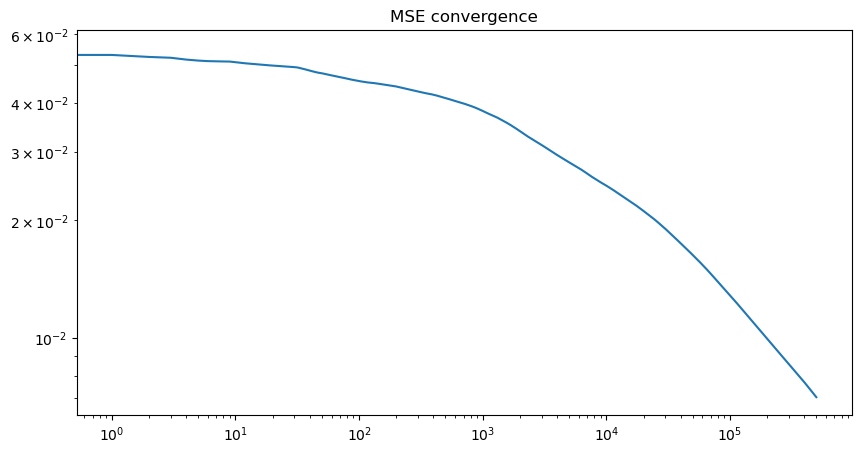

In [48]:
np.random.seed(0)

# =====================================================
# MODEL : Wiener chaos <= 2
# =====================================================

beta1 = 0.5
beta2 = 0.3
gamma = 0.2

def model(X):
    x1, x2 = X
    return beta1*x1 + beta2*x2 + gamma*x1*x2


Var = beta1**2 + beta2**2 + gamma**2

S_star = np.array([
    beta1**2,
    beta2**2,
    gamma**2
]) / Var

print("True Sobol:", S_star)

# =====================================================
# Möbius inverse matrix
# order = ({1}, {2}, {1,2})
# M^{-1}_{u,v} = 1_{v ⊂ u}
# =====================================================

M_inv = np.array([
    [1,0,0],
    [0,1,0],
    [1,1,1]
], dtype=float)


# =====================================================
# Gaussian sampling
# =====================================================

def sample_X():
    return np.random.randn(2)


# =====================================================
# Pick-Freeze
# =====================================================

def pick_freeze(subset, X, Xp):

    X_pf = X.copy()

    if subset == 0:        # freeze X1
        X_pf[1] = Xp[1]

    elif subset == 1:      # freeze X2
        X_pf[0] = Xp[0]

    # subset 2 -> full set -> Y(U)=Y

    return model(X_pf)


# =====================================================
# Mirror Descent
# =====================================================

def mirror_descent(n_iter=500000, eta0=0.5):

    S = np.ones(3)/3
    S_avg = np.zeros(3)

    m = 0.0

    subsets = [0,1,2]
    probs = np.ones(3)/3

    trajectory = []

    for t in range(1, n_iter+1):

        X = sample_X()
        Xp = sample_X()

        subset = np.random.choice(subsets, p=probs)

        Y = model(X)
        Y_pf = pick_freeze(subset, X, Xp)

        # running mean
        m += (Y - m)/(t)

        # TRUE matrix product !!!
        MS = M_inv @ S

        grad = (Y-m) * M_inv[subset] * (
            (Y-m)*MS[subset] - (Y_pf-m)
        )

        gamma_t = eta0/t **0.7

        # entropic mirror step
        S = S * np.exp(-gamma_t * grad)
        S /= S.sum()

        # Polyak average
        S_avg += (S - S_avg)/t

        trajectory.append(S_avg.copy())

    return S, S_avg, np.array(trajectory)


# =====================================================
# RUN
# =====================================================

S_final, S_polyak, traj = mirror_descent()

print("\nFinal Mirror:", S_final)
print("Polyak:", S_polyak)
print("True:", S_star)


# =====================================================
# Convergence plot
# =====================================================

traj = np.array(traj)

# evolution de la mse en fonction du nombre d'itérations
mse = np.mean((traj - S_star)**2, axis=1)
plt.figure(figsize=(10,5))
plt.plot(mse)
plt.yscale('log')
plt.xscale('log')
plt.title("MSE convergence")
plt.show()  

True Sobol: [0.65789474 0.23684211 0.10526316]

Final Mirror: [0.64263173 0.2252009  0.13216736]
Polyak:       [0.63958599 0.22544988 0.13496413]
True:         [0.65789474 0.23684211 0.10526316]


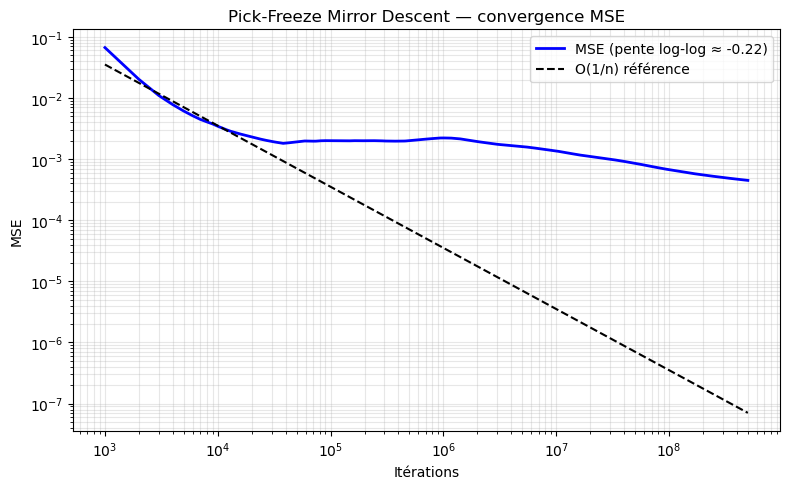

In [56]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# =====================================================
# MODEL : Wiener chaos <= 2
# =====================================================

beta1 = 0.5
beta2 = 0.3
gamma = 0.2

def model(X):
    x1, x2 = X
    return beta1*x1 + beta2*x2 + gamma*x1*x2


Var = beta1**2 + beta2**2 + gamma**2

S_star = np.array([
    beta1**2,
    beta2**2,
    gamma**2
]) / Var

print("True Sobol:", S_star)

# =====================================================
# Möbius inverse matrix
# order = ({1}, {2}, {1,2})
# M^{-1}_{u,v} = 1_{v ⊂ u}
# =====================================================

M_inv = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [1, 1, 1]
], dtype=float)


# =====================================================
# Gaussian sampling
# =====================================================

def sample_X():
    return np.random.randn(2)


# =====================================================
# Pick-Freeze
# X^{(u)}_i = X_i si i in u, X'_i sinon
# =====================================================

def pick_freeze(subset_idx, X, Xp):
    """
    subset_idx: 0 -> u={1} : garde X1, remplace X2 par X'2
                1 -> u={2} : garde X2, remplace X1 par X'1
                2 -> u={1,2}: garde tout -> Y^{(u)} = Y
    """
    X_pf = X.copy()

    if subset_idx == 0:       # u={1}
        X_pf[1] = Xp[1]
    elif subset_idx == 1:     # u={2}
        X_pf[0] = Xp[0]
    # subset_idx == 2 -> u={1,2}: rien à remplacer

    return model(X_pf)


# =====================================================
# Mirror Descent (corrigé)
# =====================================================

def mirror_descent(n_iter=500000, eta0=1):

    S = np.ones(3) / 3

    # FIX 2 : moyenne arithmétique (donne O(1/n), meilleur que
    #          la moyenne Cesaro pondérée de l'article qui donne O(1/sqrt(n)))
    S_avg = np.zeros(3)

    m = 0.0

    trajectory = []

    for t in range(1, n_iter + 1):

        X  = sample_X()
        Xp = sample_X()

        subset = np.random.choice(3)

        Y    = model(X)
        Y_pf = pick_freeze(subset, X, Xp)

        m_prev = m
        m += (Y - m) / t

        # Gradient stochastique (eq. 21 de l'article)
        MS   = M_inv @ S
        grad = (Y - m_prev) * M_inv[subset] * (
            (Y - m_prev) * MS[subset] - (Y_pf - m_prev)
        )

        eta_t = eta0 / t**0.8

        log_S  = np.log(S) - eta_t * grad
        log_S -= log_S.max()
        S      = np.exp(log_S)
        S     /= S.sum()

        # Moyenne arithmétique (Polyak)
        S_avg += (S - S_avg) / t

        trajectory.append(S_avg.copy())

    return S, S_avg, np.array(trajectory)


# =====================================================
# RUN
# =====================================================

S_final, S_polyak, traj = mirror_descent()

print("\nFinal Mirror:", S_final)
print("Polyak:      ", S_polyak)
print("True:        ", S_star)


# =====================================================
# Convergence plot
# =====================================================

iters = np.arange(1, len(traj) + 1) * 1000
mse   = np.mean((traj - S_star)**2, axis=1)

# Pente log-log sur la moitié finale
slope = np.polyfit(np.log(iters[len(iters)//2:]),
                   np.log(mse[len(iters)//2:]), 1)[0]
ref_1n = mse[10] * iters[10] / iters

plt.figure(figsize=(8, 5))
plt.loglog(iters, mse,    'b-',  lw=2,   label=f'MSE (pente log-log ≈ {slope:.2f})')
plt.loglog(iters, ref_1n, 'k--', lw=1.5, label='O(1/n) référence')
plt.xlabel("Itérations")
plt.ylabel("MSE")
plt.title("Pick-Freeze Mirror Descent — convergence MSE")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

True S* = [0.19047619 0.04761905 0.76190476]

Variance Unif : [0.00050402 0.00034226 0.00086074]
Variance Adapt: [0.00035573 0.00024427 0.00058967]


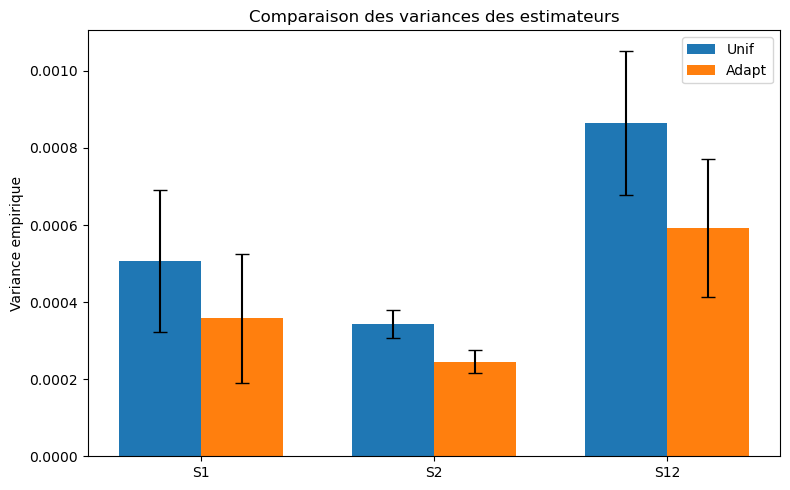

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Problem setup
# -----------------------------
def f_val(x1, x2, alpha, beta, gamma):
    return alpha*x1 + beta*x2 + gamma*x1*x2

def sobol_exact_normal(alpha, beta, gamma):
    D = alpha**2 + beta**2 + gamma**2
    return np.array([alpha**2/D, beta**2/D, gamma**2/D], dtype=float)

Q = 3

M_inv = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [1.0, 1.0, 1.0],
], dtype=float)

# -----------------------------
# Simplex projection
# -----------------------------
def proj_simplex(v):
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u - (cssv - 1) / (np.arange(len(v))+1) > 0)[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    return np.maximum(v - theta, 0.0)

def proj_simplex_lower(v, a_min):
    q = len(v)
    w = (v - a_min) / (1.0 - q*a_min)
    w = proj_simplex(w)
    return a_min + (1.0 - q*a_min)*w

# -----------------------------
# Core simulation (vectorized over R)
# -----------------------------
def run_many(
    R, N,
    alpha=1.0, beta=0.5, gamma=2.0,
    step_c=0.5, step_alpha=0.7,
    policy="unif",
    burn_in=1000,
    a_min=0.02,
    gamma_ema_scalar=0.02,
    mix_power=0.3,
    seed=0
):
    rng = np.random.default_rng(seed)

    S = np.ones((R,Q)) / Q
    S_bar = np.zeros((R,Q))
    a = np.ones((R,Q)) / Q

    # moments
    n_mom = np.zeros(R)
    mean = np.zeros(R)
    M2 = np.zeros(R)

    G = np.zeros((R,Q))

    S_star = sobol_exact_normal(alpha, beta, gamma)

    for n in range(1, N+1):
        gamma_n = step_c * (n**(-step_alpha))

        # sample subset indices
        idx = np.array([rng.choice(Q, p=a[r]) for r in range(R)])

        # generate samples
        x1 = rng.normal(size=R)
        x2 = rng.normal(size=R)
        x1p = rng.normal(size=R)
        x2p = rng.normal(size=R)

        y = f_val(x1, x2, alpha, beta, gamma)

        yu = np.empty(R)
        mask0 = idx == 0
        mask1 = idx == 1
        mask2 = idx == 2

        yu[mask0] = f_val(x1[mask0], x2p[mask0], alpha, beta, gamma)
        yu[mask1] = f_val(x1p[mask1], x2[mask1], alpha, beta, gamma)
        yu[mask2] = y[mask2]

        # Welford (safe version)
        n_mom += 1
        d = y - mean
        mean += d / n_mom
        M2 += d * (y - mean)

        yt = y - mean
        yut = yu - mean

        # gradient
        rows = M_inv[idx]
        MinvS = np.sum(rows * S, axis=1)

        scalar = yt * (yt*MinvS - yut)
        g = rows * scalar[:,None]

        # mirror descent
        S *= np.exp(-gamma_n * g)
        S /= S.sum(axis=1, keepdims=True)

        # Polyak averaging
        S_bar += (S - S_bar)/n

        # adaptation
        if policy == "cf":
            val = np.zeros(R)

            val[mask0] = (yt[mask0]**2)*(yt[mask0]*S_bar[mask0,0] - yut[mask0])**2
            val[mask1] = (yt[mask1]**2)*(yt[mask1]*S_bar[mask1,1] - yut[mask1])**2
            val[mask2] = (yt[mask2]**2)*(yt[mask2] - yut[mask2])**2

            G[np.arange(R), idx] = (
                (1-gamma_ema_scalar)*G[np.arange(R), idx]
                + gamma_ema_scalar*val
            )

            if n > burn_in:
                w1 = np.sqrt(np.maximum(G[:,0]-G[:,2],1e-12))
                w2 = np.sqrt(np.maximum(G[:,1]-G[:,2],1e-12))
                w12 = np.sqrt(np.maximum(G[:,2],1e-12))

                a_cf = np.stack([w1,w2,w12], axis=1)
                a_cf /= a_cf.sum(axis=1, keepdims=True)

                rho = n**(-mix_power)
                a = (1-rho)*a_cf + rho*(np.ones((R,Q))/Q)

                for r in range(R):
                    a[r] = proj_simplex_lower(a[r], a_min)

        else:
            a[:] = 1.0/Q

    return S_bar, S_star


# -----------------------------
# Analysis: variance + boxplots
# -----------------------------
def compare_variances(N=5000, R=100):
    Sbar_u, S_star = run_many(R, N, policy="unif", seed=0)
    Sbar_cf, _ = run_many(R, N, policy="cf", seed=1)

    # variances
    var_u = np.var(Sbar_u, axis=0)
    var_cf = np.var(Sbar_cf, axis=0)

    print("True S* =", S_star)
    print("\nVariance Unif :", var_u)
    print("Variance Adapt:", var_cf)

    # boxplots
    labels = ["S1", "S2", "S12"]
        
    var_u, se_u = summarize_variance(Sbar_u)
    var_cf, se_cf = summarize_variance(Sbar_cf)

    labels = ["S1", "S2", "S12"]
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8,5))

    plt.bar(x - width/2, var_u, width, yerr=se_u, capsize=5, label="Unif")
    plt.bar(x + width/2, var_cf, width, yerr=se_cf, capsize=5, label="Adapt")

    plt.xticks(x, labels)
    plt.ylabel("Variance empirique")
    plt.title("Comparaison des variances des estimateurs")
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_variance(Sbars):
    # Sbars shape: (R, d)
    
    var = np.var(Sbars, axis=0, ddof=1) 
    se = bootstrap_var(Sbars)
    return var, se

def bootstrap_var(Sbars, B=500):
    R, d = Sbars.shape
    vars_boot = np.zeros((B, d))

    for b in range(B):
        idx = np.random.choice(R, R, replace=True)
        sample = Sbars[idx]
        vars_boot[b] = np.var(sample, axis=0, ddof=1)

    return np.std(vars_boot, axis=0)


# -----------------------------
# Run
# -----------------------------
if __name__ == "__main__":
    compare_variances(N=50000, R=200)